# 🔴 **Import Libs**

In [ ]:
pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 22.4 MB/s eta 0:00:00


In [ ]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2 as cv
import PIL
from PIL import Image

import sklearn
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch import optim
from torch.nn import functional as F

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import tqdm
import torchmetrics as tm

In [ ]:
!python --version

Python 3.12.13


In [ ]:
for lib in [np, pd, cv, PIL, sklearn, torch, torchvision, tqdm, tm]:
  print(lib.__name__, '-->', lib.__version__)

numpy --> 2.0.2
pandas --> 2.2.2
cv2 --> 4.13.0
PIL --> 11.3.0
sklearn --> 1.6.1
torch --> 2.11.0+cu128
torchvision --> 0.26.0+cu128
tqdm --> 4.67.3
torchmetrics --> 1.9.0


# 🔴 **Utils**

In [ ]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

In [ ]:
def num_trainable_params(model):
  nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
  return nums

# 🔴 **Dataset**

## 🟠 **Copy & Unzip the Dataset**

In [ ]:
import os
import zipfile
from pathlib import Path

# تعریف مسیر پایه پروژه به صورت داینامیک
IS_COLAB = "google.colab" in str(get_ipython()) if "get_ipython" in globals() else False

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path("/content")
    ZIP_PATH = Path("/content/drive/MyDrive/UTKFace.zip")
    DATA_DIR = BASE_DIR / "UTKFace"

    # اکسترکت دیتاست فقط در صورتی که پوشه وجود نداشته باشد
    if not DATA_DIR.exists() and ZIP_PATH.exists():
        print("Extracting dataset in Colab...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(BASE_DIR)
else:
    BASE_DIR = Path(".")
    DATA_DIR = BASE_DIR / "data" / "UTKFace"

print(f"Data Directory set to: {DATA_DIR.resolve()}")


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# from pathlib import Path

# DATA_DIR = Path("./data/UTKFace") if Path("./data/UTKFace").exists() else Path("/content/UTKFace")


In [ ]:
# !cp "/content/drive/MyDrive/UTKFace.zip" "/content/"

In [ ]:
# !unzip -q /content/UTKFace.zip

## 🟠 EDA

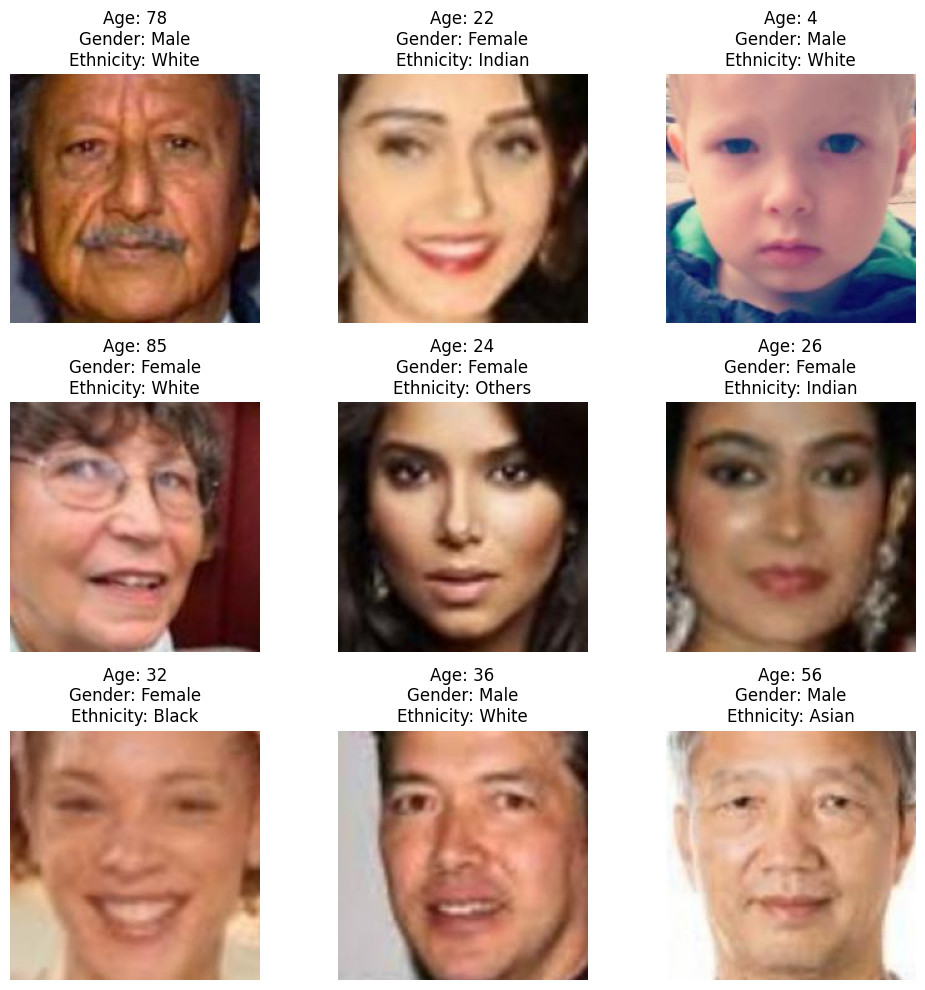

In [ ]:
# Replace with the actual path to your UTK dataset images folder
dataset_folder = '/content/UTKFace'

def show_random_samples(num_samples=9):
    image_files = os.listdir(dataset_folder)
    selected_image_files = random.sample(image_files, num_samples)

    plt.figure(figsize=(10, 10))
    for idx, image_file in enumerate(selected_image_files, 1):
        image_path = os.path.join(dataset_folder, image_file)
        age, gender, ethnicity = image_file.split('_')[:3]

        image = Image.open(image_path)

        gender = 'Male' if int(gender) == 0 else 'Female'
        ethnicity = ['White', 'Black', 'Asian', 'Indian', 'Others'][int(ethnicity)]

        plt.subplot(3, 3, idx)
        plt.imshow(image)
        plt.title(f"Age: {age}\nGender: {gender}\nEthnicity: {ethnicity}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# Call the function to display random samples
show_random_samples()


In [ ]:
print(len(os.listdir(dataset_folder)))


23708


### 🟡 Creating a csv file which contains labels

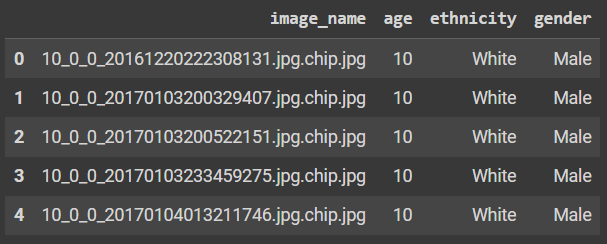

In [ ]:
image_names = []
ages = []
ethnicities = []
genders = []

for filename in os.listdir(dataset_folder):
    if filename.endswith('.jpg'):
        parts = filename.split('_')
        if (len(parts) < 4):
            continue

        age = int(parts[0])
        gender = 'Male' if int(parts[1]) == 0 else 'Female'
        ethnicity = ['White', 'Black', 'Asian', 'Indian', 'Others'][int(parts[2])]

        if (age > 80):
            continue

        image_names.append(filename)
        ages.append(age)
        ethnicities.append(ethnicity)
        genders.append(gender)



data = {'image_name': image_names,
        'age': ages,
        'ethnicity': ethnicities,
        'gender': genders}

df = pd.DataFrame(data)

csv_filename = 'UTKFace.csv'
df.to_csv(csv_filename, index=False)
print(f"CSV File '{csv_filename}' created successfully")

CSV File 'UTKFace.csv' created successfully


In [ ]:
df


,image_name,age,ethnicity,gender
0,24_0_0_20170111181750330.jpg.chip.jpg,24,White,Male
1,25_0_1_20170113133108944.jpg.chip.jpg,25,Black,Male
2,55_0_4_20170117204624770.jpg.chip.jpg,55,Others,Male
3,41_1_1_20170117171024861.jpg.chip.jpg,41,Black,Female
4,78_0_0_20170120224525249.jpg.chip.jpg,78,White,Male
...,...,...,...,...
23160,9_0_1_20170110220605937.jpg.chip.jpg,9,Black,Male
23161,40_0_4_20170104201550378.jpg.chip.jpg,40,Others,Male
23162,65_1_0_20170103184138483.jpg.chip.jpg,65,White,Female
23163,64_0_2_20170116193332398.jpg.chip.jpg,64,Asian,Male


### 🟡 Plot histogram for age, gender and, ethnicity


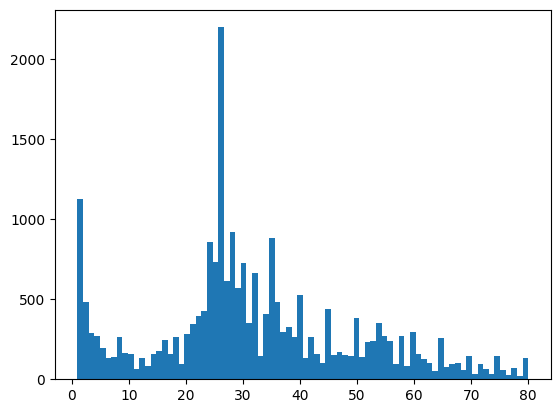

In [ ]:
plt.hist(df.age, bins=len(df.age.unique()));

In [ ]:
df.age.describe()

,age
count,23165.000000
mean,32.024218
std,18.227409
min,1.000000
25%,23.000000
50%,29.000000
75%,42.000000
max,80.000000


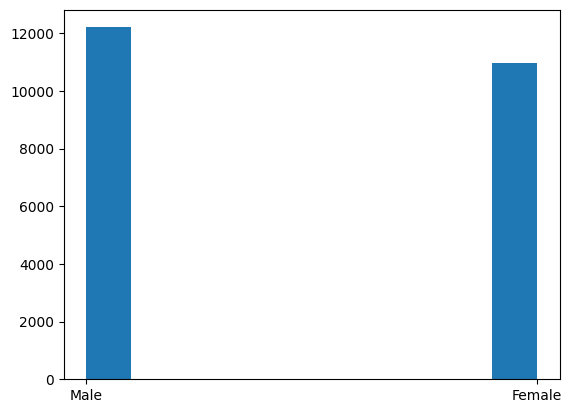

In [ ]:
plt.hist(df.gender);  # plt.hist(df.gender, bins=2, rwidth=0.5);

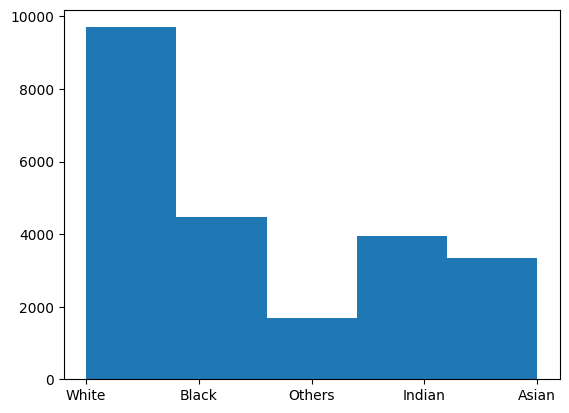

In [ ]:
plt.hist(df.ethnicity, bins=len(df.ethnicity.unique()));

In [ ]:
df.ethnicity.value_counts()

,count
ethnicity,
White,9698
Black,4478
Indian,3952
Asian,3348
Others,1689


### 🟡 Calculating the cross-tabulation of gender and ethnicity using the pandas.crosstab() function.

In [ ]:
pd.crosstab(index=df.gender, columns=df.ethnicity)

ethnicity,Asian,Black,Indian,Others,White
gender,,,,,
Female,1810,2182,1698,930,4337
Male,1538,2296,2254,759,5361


### 🟡 Creating violin plots and box plots for age, separately for men and women.

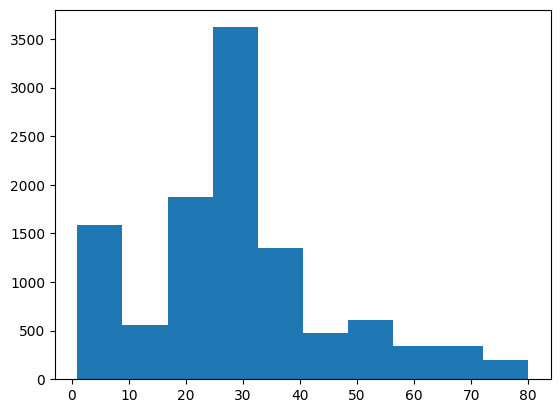

In [ ]:
plt.hist(df.age[df.gender == 'Female']);

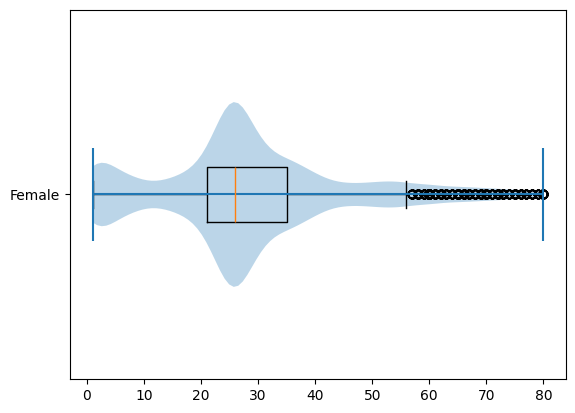

In [ ]:
plt.boxplot(df.age[df.gender == 'Female'], vert=False, tick_labels=['Female']);
plt.violinplot(df.age[df.gender == 'Female'], vert=False);

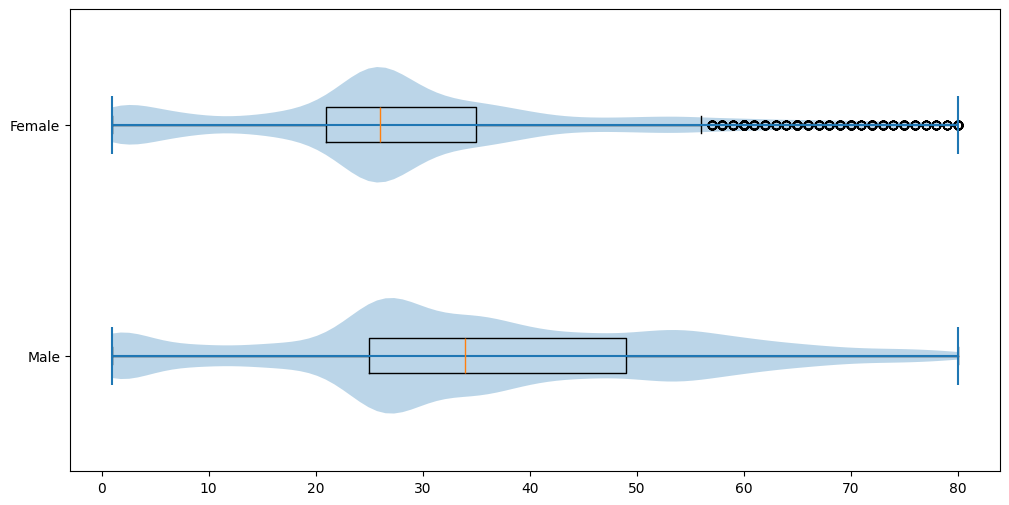

In [ ]:
plt.figure(figsize=(12,6))
plt.boxplot([df.age[df.gender == cat] for cat in df.gender.unique()] , vert=False, tick_labels=df.gender.unique());
plt.violinplot([df.age[df.gender == cat] for cat in df.gender.unique()],  vert=False);

### 🟡 Creating violin plots and box plots for age, separately for each ethnicity.

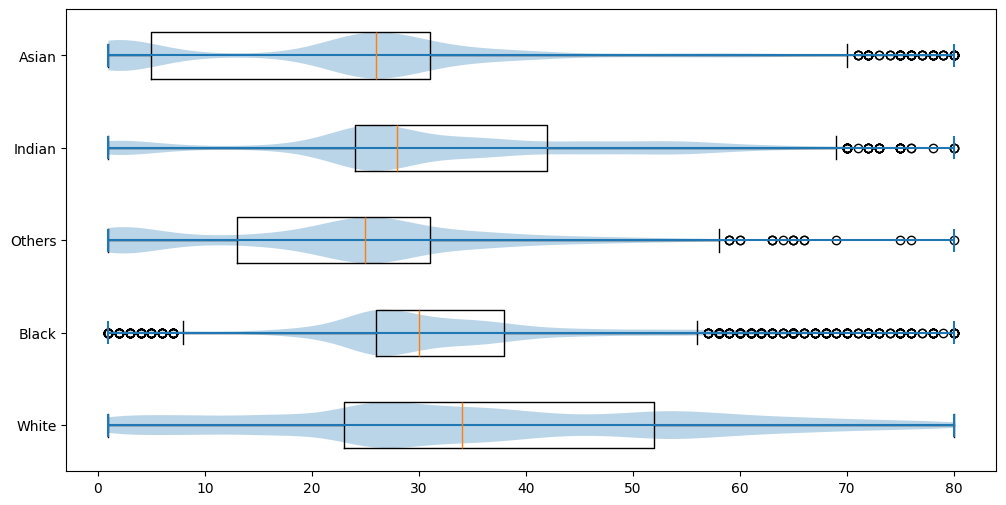

In [ ]:
plt.figure(figsize=(12,6))
plt.boxplot([df.age[df.ethnicity == cat] for cat in df.ethnicity.unique()], vert=False, tick_labels=df.ethnicity.unique());
plt.violinplot([df.age[df.ethnicity == cat] for cat in df.ethnicity.unique()], vert=False);

## 🟠 Splitting datasets

In [ ]:
df_train, temp = train_test_split(df, test_size=0.3, stratify=df.age, random_state=42)
df_test, df_valid = train_test_split(temp, test_size=0.5, stratify = temp.age, random_state=42)
df_train.shape, temp.shape
df_train.shape, df_test.shape, df_valid.shape

((16215, 4), (3475, 4), (3475, 4))

In [ ]:
df_train.head()

,image_name,age,ethnicity,gender
7804,58_0_0_20170105173636909.jpg.chip.jpg,58,White,Male
4416,24_1_0_20170116220128735.jpg.chip.jpg,24,White,Female
17049,28_1_2_20170116171710952.jpg.chip.jpg,28,Asian,Female
597,6_1_0_20170109201628566.jpg.chip.jpg,6,White,Female
16850,52_0_4_20170104212316604.jpg.chip.jpg,52,Others,Male


In [ ]:
df_test.head()

,image_name,age,ethnicity,gender
1440,56_1_3_20170109132208103.jpg.chip.jpg,56,Indian,Female
2348,48_0_3_20170119202007642.jpg.chip.jpg,48,Indian,Male
5752,34_0_0_20170116030432644.jpg.chip.jpg,34,White,Male
4856,46_0_1_20170113175110660.jpg.chip.jpg,46,Black,Male
19020,4_1_3_20161219230403672.jpg.chip.jpg,4,Indian,Female


🟡 Plotting histograms for age in the training, validation, and test sets.

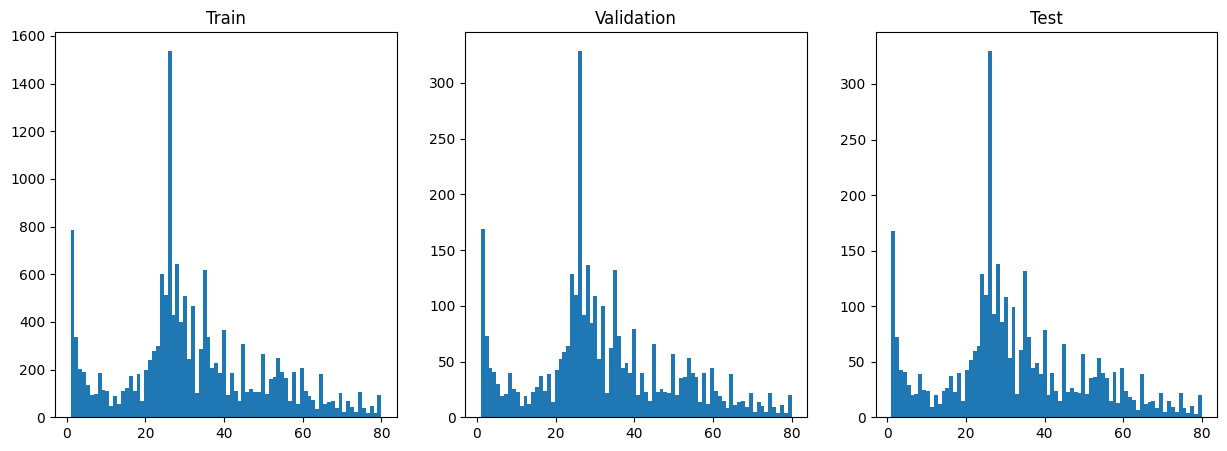

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].hist(df_train.age, bins=len(df_train.age.unique())); axes[0].set_title('Train')
axes[1].hist(df_valid.age, bins=len(df_valid.age.unique())); axes[1].set_title('Validation')
axes[2].hist(df_test.age, bins=len(df_test.age.unique())); axes[2].set_title('Test');

### 🟡 Saving the training, validation, and test sets in separate CSV files.

In [ ]:
df_train.to_csv('train_set.csv', index=False)
df_valid.to_csv('valid_set.csv', index=False)
df_test.to_csv('test_set.csv', index=False)

print('All CSV files created successfully.')

All CSV files created successfully.


## 🟠 Defining transformations

In [ ]:
train_transform = transforms.Compose([transforms.Resize((128,128)),
                                      transforms.RandomHorizontalFlip(),
                                      transforms.RandomRotation(degrees=15),
                                      transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                                     ])

test_transform = transforms.Compose([transforms.Resize((128,128)),
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
                                     ])

🟠 Custom dataset

In [ ]:
from PIL import Image
import torch
from torch.utils.data import Dataset

class UTKDataset(Dataset):
    def __init__(self, df, root_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.root_dir = Path(root_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image_name']
        img_path = self.root_dir / img_name

        # تضمین تبدیل تصویر به 3 کانال RGB
        image = Image.open(img_path).convert('RGB')

        # دریافت مقدار سن و تبدیل به تانسور float32 با بعد [1]
        age = float(self.df.iloc[idx]['age'])
        age = torch.tensor([age], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        # ارسال متادیتاها برای ارزیابی و Error Analysis بعدی
        gender = int(self.df.iloc[idx]['gender'])
        ethnicity = int(self.df.iloc[idx]['ethnicity'])

        return {
            'image': image,
            'age['image_name']
        img_path = self.root_dir / img_name

        # تضمین تبدیل تصویر به 3 کانال RGB
        image = Image.open(img_path).convert('RGB')

        # دریافت مقدار سن و تبدیل به تانسور float32 با بعد [1]
        age = float(self.df.iloc[idx]['age'])
        age = torch.tensor([age], dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        # ارسال متادیتاها برای ارزیابی و Error Analysis بعدی
        gender = int(self.df.iloc[idx]['gender'])
        ethnicity = int(self.df.iloc[idx]['ethnicity'])

        return {
            'image': image,
            'age': age,
            'gender': gender,
            'ethnicity': ethnicity
        }


In [ ]:
# class UTKDataset(Dataset):

#     def __init__(self, root_dir, csv_file, transform=None):
#         self.root_dir = root_dir
#         self.csv_file = csv_file
#         self.transform = transform
#         self.data = pd.read_csv(csv_file)
#         self.gender_dict = {'Male': 0, 'Female': 1}
#         self.ethnicity_dict = {'White': 0, 'Black': 1, 'Asian': 2, 'Indian': 3, 'Others': 4}

#     def __len__(self):
#         return len(self.data)

#     def __getitem__(self, idx):
#         sample = self.data.iloc[idx, :]
#         img_name = sample.image_name
#         img = Image.open(os.path.join(self.root_dir, img_name))
#         age = torch.tensor([sample.age], dtype = torch.float32)
#         gender = torch.tensor(self.gender_dict[sample.gender], dtype = torch.int32)
#         ethnicity = sample.ethnicity
#         img = self.transform(img)

#         return img, age #, gender, ethnicity

In [ ]:
temp_Dataset = UTKDataset(root_dir = '/content/UTKFace', csv_file = 'valid_set.csv', transform = test_transform)

temp_Dataset.data, len(temp_Dataset)
temp_Dataset[10][1]

tensor([20.])

In [ ]:
dataset_dir = '/content/UTKFace'
train_set = UTKDataset(root_dir = dataset_dir, csv_file = 'train_set.csv', transform = train_transform)
valid_set = UTKDataset(root_dir = dataset_dir, csv_file = 'valid_set.csv', transform = test_transform)
test_set = UTKDataset(root_dir = dataset_dir, csv_file = 'test_set.csv', transform = test_transform)


In [ ]:
idx = torch.randint(len(train_set), (1,))
img, age = train_set[idx.item()]
print(int(age.item()))
img

1


tensor([[[-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179],
         [-2.1179, -2.1179, -2.1179,  ..., -2.1179, -2.1179, -2.1179]],

        [[-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0357, -2.0357, -2.0357,  ..., -2.0357, -2.0357, -2.0357]],

        [[-1.8044, -1.8044, -1.8044,  ..., -1.8044, -1.8044, -1.8044],
         [-1.8044, -1.8044, -1.8044,  ..., -1

In [ ]:
idx_valid = torch.randint(len(valid_set), (1,))
imgval, age = valid_set[idx_valid.item()]
print(int(age.item()))
imgval

49


tensor([[[ 0.5193,  0.7933,  1.0331,  ..., -2.1179, -2.1179, -2.1179],
         [ 0.6392,  0.8618,  0.9817,  ..., -2.1179, -2.1179, -2.1179],
         [ 0.6392,  0.8618,  0.9132,  ..., -2.1179, -2.1179, -2.1179],
         ...,
         [-1.9809, -2.0152, -1.9638,  ..., -2.1179, -2.1179, -2.1179],
         [-1.9295, -1.9638, -1.9809,  ..., -2.1179, -2.1179, -2.1179],
         [-1.9638, -1.9295, -1.9467,  ..., -2.1179, -2.1179, -2.1179]],

        [[ 0.3978,  0.6954,  0.9580,  ..., -2.0357, -2.0357, -2.0357],
         [ 0.5203,  0.7479,  0.9055,  ..., -2.0357, -2.0357, -2.0357],
         [ 0.5203,  0.7479,  0.8179,  ..., -2.0357, -2.0357, -2.0357],
         ...,
         [-1.9832, -1.9832, -1.9482,  ..., -2.0357, -2.0357, -2.0357],
         [-1.9482, -1.9832, -1.9832,  ..., -2.0357, -2.0357, -2.0357],
         [-2.0182, -1.9657, -1.9482,  ..., -2.0357, -2.0357, -2.0357]],

        [[ 0.1128,  0.4265,  0.7228,  ..., -1.8044, -1.8044, -1.8044],
         [ 0.2348,  0.4962,  0.6531,  ..., -1

In [ ]:
idx_test = torch.randint(len(test_set), (1,))
imgtest, age = test_set[idx_test.item()]
print(int(age.item()))
imgtest

23


tensor([[[ 1.3755,  1.5125,  1.6495,  ...,  0.2111,  0.1939,  0.1939],
         [ 1.3242,  1.4612,  1.5982,  ...,  0.2111,  0.2111,  0.1939],
         [ 1.2899,  1.4269,  1.5639,  ...,  0.2282,  0.2282,  0.2111],
         ...,
         [ 0.4679,  0.4679,  0.4508,  ..., -1.1075, -1.0904, -1.0733],
         [ 0.4679,  0.4679,  0.4508,  ..., -1.0562, -1.0562, -1.0390],
         [ 0.4679,  0.4679,  0.4508,  ..., -0.8335, -0.8507, -0.8507]],

        [[ 0.6954,  0.8354,  0.9755,  ..., -0.3725, -0.3901, -0.3901],
         [ 0.6429,  0.7829,  0.9230,  ..., -0.3725, -0.3725, -0.3901],
         [ 0.6078,  0.7479,  0.8880,  ..., -0.3550, -0.3725, -0.3725],
         ...,
         [-0.0049, -0.0049, -0.0224,  ..., -1.3354, -1.3179, -1.3004],
         [-0.0049, -0.0049, -0.0224,  ..., -1.2829, -1.2829, -1.2654],
         [-0.0049, -0.0049, -0.0224,  ..., -1.0553, -1.0728, -1.0728]],

        [[ 0.5136,  0.6531,  0.7925,  ..., -0.5321, -0.5495, -0.5495],
         [ 0.4614,  0.6008,  0.7402,  ..., -0

## 🟠 dataloader

In [ ]:
train_loader = DataLoader(train_set, batch_size = 128, shuffle = True)
valid_loader = DataLoader(valid_set, batch_size = 128, shuffle = True)
test_loader = DataLoader(test_set, batch_size = 128, shuffle = True)

In [ ]:
train_iter = iter(train_loader)
train_iter

In [ ]:
next(iter(train_iter))

[tensor([[[[-2.0837, -2.0837, -2.0837,  ..., -2.0837, -2.0837, -2.0837],
           [-2.0837, -2.0837, -2.0837,  ..., -2.0837, -2.0837, -2.0837],
           [-2.0837, -2.0837, -2.0837,  ..., -2.0837, -2.0837, -2.0837],
           ...,
           [-2.0837, -2.0837, -2.0837,  ..., -2.0837, -2.0837, -2.0837],
           [-2.0837, -2.0837, -2.0837,  ..., -2.0837, -2.0837, -2.0837],
           [-2.0837, -2.0837, -2.0837,  ..., -2.0837, -2.0837, -2.0837]],
 
          [[-2.0007, -2.0007, -2.0007,  ..., -2.0007, -2.0007, -2.0007],
           [-2.0007, -2.0007, -2.0007,  ..., -2.0007, -2.0007, -2.0007],
           [-2.0007, -2.0007, -2.0007,  ..., -2.0007, -2.0007, -2.0007],
           ...,
           [-2.0007, -2.0007, -2.0007,  ..., -2.0007, -2.0007, -2.0007],
           [-2.0007, -2.0007, -2.0007,  ..., -2.0007, -2.0007, -2.0007],
           [-2.0007, -2.0007, -2.0007,  ..., -2.0007, -2.0007, -2.0007]],
 
          [[-1.7696, -1.7696, -1.7696,  ..., -1.7696, -1.7696, -1.7696],
           [-

In [ ]:
imgs, ages = next(train_iter)
imgs.shape, ages.shape

(torch.Size([128, 3, 128, 128]), torch.Size([128, 1]))

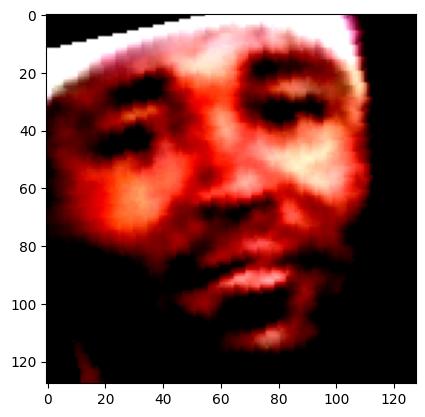

In [ ]:
plt.imshow(imgs[23].permute(1, 2, 0))

# 🔴 **Model**

In [ ]:
# cache_dir = os.path.expanduser("~/.cache/torch/hub/checkpoints")
# for f in os.listdir(cache_dir):
#     if f.startswith("resnet50"):
#         os.remove(os.path.join(cache_dir, f))
#         print(f"Deleted: {f}")

In [ ]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
model.fc = nn.Linear(in_features = 2048, out_features = 1, bias = True)
model

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
import torch.nn as nn
from torchvision import models

class AgeEstimationResNet50(nn.Module):
    def __init__(self, pretrained=True, freeze_backbone=True):
        super().__init__()
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        self.backbone = models.resnet50(weights=weights)

        # انجماد لایه‌های فیچر در ابتدا
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # جایگزینی لایه نهایی رگرسیون با Dropout برای جلوگیری از Overfitting
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features,  = delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False

    def __call__(self, val_loss):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.counter = 0


def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    for batch in tqdm(dataloader, desc="Training", leave=False):
        images = batch['image'].to(device)
        targets = batch['age'].to(device)

        optimizer.zero_grad()
        preds = model(images)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
    return running_loss / len(dataloader.dataset)


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            targets = batch['age'].to(device)

            preds = model(images)
            loss = criterion(preds, targets)
            running_loss += loss.item() * images.size(0)

    return running_loss / len(dataloader.dataset)


def run_training(model, train_loader, val_loader, criterion, optimizer, scheduler,
                 epochs, device, save_path="best_age_model.pth", patience=5):

    early_stopping = EarlyStopping(patience=patience)
    best_val_loss = float('inf')
    best_weights = copy.deepcopy(model.state_dict())

    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(1, epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, val_loader, criterion, device)

        # به‌روزرسانی نرخ یادگیری بر اساس خطای اعتبارسنجی
        if scheduler:
            scheduler.step(val_loss)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        print(f"Epoch [{epoch:02d}/{epochs}] - Train MAE: {train_loss:.3f} | Val MAE: {val_loss:.3f} | LR: {optimizer.param_groups[0]['lr']:.6f}")

        # ذخیره وزن‌های برتر
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, save_path)
            print(f"  --> Checkpoint saved: New best Val MAE = {val_loss:.3f}")

        # بررسی شرط توقف زودرس
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    # بازگرداندن بهترین وزن‌ها به مدل
    model.load_state_dict(best_weights)
    print(f"Training finished. Best Val MAE: {best_val_loss:.3f}")
    return history


In [ ]:
# class AgeEstimationModel(nn.Module):

#   def __init__(self):
#     super().__init__()
#     self.model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
#     self.model.fc = nn.Linear(in_features = 2048, out_features = 1, bias = True)

#   def forward(self, x):
#     y = self.model(x)
#     return y

In [ ]:
model(imgs).shape

torch.Size([128, 1])

🔰 Creating an object for model using the AgeEstimationModel class you've created.

In [ ]:
model = AgeEstimationModel()
model(imgs).shape

torch.Size([128, 1])

# 🔴 **Config**

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [ ]:
model = model.to(device)

In [ ]:
loss_fn = nn.L1Loss()

In [ ]:
optimizer = optim.SGD(model.parameters(), lr = 0.02, momentum = 0.9, weight_decay = 1e-4)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.02
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0001
)

In [ ]:
metric = tm.MeanAbsoluteError().to(device)
metric

MeanAbsoluteError()

In [ ]:
metric(torch.tensor(6.), torch.tensor(4.))

tensor(2., device='cuda:0')

In [ ]:
metric.compute()

tensor(2., device='cuda:0')

# 🔴 **Train ➰**

In [ ]:
# epochs = 100
# for epoch in range(epochs):
#     for inputs, targets, _, _ in train_loader:
#         outputs = model(inputs)
#         loss = loss_fn(outputs, targets)
#         loss.backward()
#         optimzier.step()
#         optimizer.zero_grad()
#         print(loss)

In [ ]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch=None):
    model.train()
    loss_train = AverageMeter()
    metric.reset()
    with tqdm.tqdm(train_loader, unit='batch') as tepoch:
        for inputs, targets in tepoch:
            if epoch is not None:
                tepoch.set_description(f'Epoch {epoch}')
            inputs = inputs.to(device)
            targets = targets.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_train.update(loss.item(), n=len(targets))
            metric.update(outputs, targets)

            tepoch.set_postfix(loss=loss_train.avg, metric=metric.compute().item())
        return model, loss_train.avg, metric



In [ ]:
with tqdm.tqdm(range(1000000)) as aa:
    for a in aa:
        b = np.exp(a/1000000)

100%|██████████| 1000000/1000000 [00:01<00:00, 777412.84it/s]


In [ ]:
train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch=1)

Epoch 1: 100%|██████████| 127/127 [01:54<00:00,  1.11batch/s, loss=11.2, metric=11.2]


(AgeEstimationModel(
   (model): ResNet(
     (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
     (layer1): Sequential(
       (0): Bottleneck(
         (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
         (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (relu): ReLU(inplace=True)
         (downsample

# 🔴 **Evaluation ➰**

In [ ]:
def evaluate(model, test_loader, loss_fn, metric):
  model.eval()
  loss_eval = AverageMeter()
  metric.reset()

  with torch.no_grad():
    for inputs, targets in test_loader:
      inputs = inputs.to(device)
      targets = targets.to(device)
      outputs = model(inputs)
      loss = loss_fn(outputs, targets)
      loss_eval.update(loss.item(), n=len(targets))
      metric(outputs, targets)
  return loss_eval.avg, metric.compute().item()

In [ ]:
evaluate(model, valid_loader, loss_fn, metric)

(7.8550115213462774, 7.855011463165283)

### 🟡 Error Analysis

In [ ]:
# Error per Age Group & Bias & Fairness Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def run_error_analysis(model, test_loader, test_df, device):
    model.eval()
    all_preds = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Running Inference on Test Set"):
            images = batch['image'].to(device)
            preds = model(images)
            all_preds.extend(preds.squeeze().cpu().numpy())

    # افزودن پیش‌بینی‌ها و خطا به دیتافریم تست
    results_df = test_df.copy()
    results_df['predicted_age'] = all_preds
    results_df['absolute_error'] = np.abs(results_df['age'] - results_df['predicted_age'])

    # تعریف رده‌های سنی
    bins = [0, 12, 25, 45, 60, 85]
    labels = ['Child (0-12)', 'Youth (13-25)', 'Adult (26-45)', 'Middle-Aged (46-60)', 'Senior (61+)']
    results_df['age_group'] = pd.cut(results_df['age'], bins=bins, labels=labels, right=False)

    # 1. نمودار MAE بر اساس رده سنی
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    age_group_mae = results_df.groupby('age_group')['absolute_error'].mean().reset_index()
    sns.barplot(data=age_group_mae, x='age_group', y='absolute_error', palette='Blues_d')
    plt.title('MAE by Age Group')
    plt.ylabel('Mean Absolute Error (Years)')
    plt.xlabel('Age Group')
    plt.xticks(rotation=25)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # 2. نمودار MAE بر اساس قومیت (Fairness Check)
    plt.subplot(1, 2, 2)
    ethnicity_map = {0: 'White', 1: 'Black', 2: 'Asian', 3: 'Indian', 4: 'Others'}
    results_df['ethnicity_name'] = results_df['ethnicity'].map(ethnicity_map)
    eth_mae = results_df.groupby('ethnicity_name')['absolute_error'].mean().reset_index()
    sns.barplot(data=eth_mae, x='ethnicity_name', y='absolute_error', palette='viridis')
    plt.title('MAE by Ethnicity (Fairness)')
    plt.ylabel('Mean Absolute Error (Years)')
    plt.xlabel('Ethnicity')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    return results_df


# 🔴 **Training Process 〽️**

## 🟠 Finding Hyper-parameters

### 🟡 Calculating the loss for an untrained model using a few batches.


In [ ]:
model = AgeEstimationModel().to(device)

with torch.no_grad():
  inputs, targets = next(iter(train_loader))
  inputs = inputs.to(device)
  targets = targets.to(device)

  outputs = model(inputs)
  loss = loss_fn(outputs, targets)

print(loss)

tensor(33.3489, device='cuda:0')


In [ ]:
torch.cuda.empty_cache()

temp = torch.tensor(1., device = device)
model = temp.clone()
optimizer = temp.clone()
inputs = temp.clone()
targets = temp.clone()
outputs = temp.clone()

### 🟡 Trying to train and overfit the model on a small subset of the dataset.

In [ ]:
mini_train_size = 1000
mini_train_dataset, _ = random_split(train_set, [mini_train_size, len(train_set) - mini_train_size])
mini_train_loader = DataLoader(mini_train_dataset, 20)

In [ ]:
len(mini_train_dataset)

1000

In [ ]:
model = AgeEstimationModel().to(device)
optimizer = optim.SGD(model.parameters(), lr = 1e-2, momentum = 0.9, weight_decay = 1e-4)

In [ ]:
num_epochs = 10 # Repeat for several times until loss value drop under 4
for epoch in range(num_epochs):
  model, _, _ = train_one_epoch(model, mini_train_loader, loss_fn, optimizer, metric, epoch=epoch)

Epoch 1:  60%|██████    | 30/50 [00:05<00:03,  5.86batch/s, loss=14.5, metric=14.5]


KeyboardInterrupt: 

### 🟡 Training the model for a limited number of epochs, experimenting with various learning rates.

In [ ]:
num_epochs = 3

for lr in [0.1, 0.01, 0.001, 0.0001]:
  print(f'LR = {lr}')

  model = AgeEstimationModel().to(device)
  optimizer = optim.SGD(model.parameters(), lr = lr, momentum = 0.9, weight_decay = 1e-4)

  for epoch in range(num_epochs):
    model, _, _ = train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch=epoch)


  print()

LR = 0.1


Epoch 0:   8%|▊         | 10/127 [00:10<02:04,  1.06s/batch, loss=21, metric=21]


KeyboardInterrupt: 

### 🟡 Creating a small grid using the weight decay and the best learning rate.





In [ ]:
num_epochs = 5

for lr in [0.005, 0.003, 0.001, 0.0007, 0.0005]:
  for wd in [1e-4, 1e-5, 0.]:
    print(f'LR = {lr}, WD = {wd}')

    model = AgeEstimationModel().to(device)
    optimizer = optim.SGD(model.parameters(), lr = lr, momentum = 0.9, weight_decay = wd)

    for epoch in range (num_epochs):
      model, loss, _ = train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch=epoch)
    print()

LR = 0.005, WD = 0.0001


Epoch 2:   4%|▍         | 5/127 [00:06<02:35,  1.27s/batch, loss=5.61, metric=5.61]


KeyboardInterrupt: 

### 🟡 Training model for longer epochs using the best model from step 4.





In [ ]:
model = AgeEstimationModel().to(device)


In [ ]:
lr = 0.001
wd = 1e-4
optimizer = optim.SGD(model.parameters(), lr = lr, momentum = 0.9, weight_decay = wd)

In [ ]:
loss_train_hist = []
loss_valid_hist = []

metric_train_hist = []
metric_valid_hist = []

best_loss_valid = torch.inf
epoch_counter = 0
num_epochs = 10


for epoch in range(num_epochs):
  # Train
  model, loss_train, metric_train = train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch=epoch)

  # Validation
  loss_valid, metric_valid = evaluate(model, valid_loader, loss_fn, metric)

  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)

  metric_train_hist.append(metric_train)
  metric_valid_hist.append(metric_valid)

  if loss_valid < best_loss_valid:
    best_loss_valid = loss_valid
    torch.save(model, f'model.pt')
    print('Model Saved!')


  print(f'valid: Loss = {loss_valid:.4}, ACC = {metric_valid: .4}')
  print()


  epoch_counter += 1







Epoch 0:  38%|███▊      | 48/127 [00:47<01:18,  1.00batch/s, loss=25.9, metric=25.9]


KeyboardInterrupt: 

## 🟠 Main Loop

🔰 Defining model.

In [ ]:
model = AgeEstimationModel().to(device)

🔰 Defining optimizer and Set learning rate and weight decay.

In [ ]:
lr = 0.001
wd = 1e-4
optimizer = optim.SGD(model.parameters(), lr = lr, momentum = 0.9, weight_decay = wd)

🔰 Writing code to train the model for `num_epochs` epoches.

In [ ]:
loss_train_hist = []
loss_valid_hist = []

metric_train_hist = []
metric_valid_hist = []

best_loss_valid = torch.inf
epoch_counter = 0
num_epochs = 10


for epoch in range(num_epochs):
  # Train
  model, loss_train, metric_train = train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch=epoch)

  # Validation
  loss_valid, metric_valid = evaluate(model, valid_loader, loss_fn, metric)

  loss_train_hist.append(loss_train)
  loss_valid_hist.append(loss_valid)

  metric_train_hist.append(metric_train)
  metric_valid_hist.append(metric_valid)

  if loss_valid < best_loss_valid:
    best_loss_valid = loss_valid
    torch.save(model, f'model.pt')
    print('Model Saved!')


  print(f'valid: Loss = {loss_valid:.4}, ACC = {metric_valid: .4}')
  print()


  epoch_counter += 1







Epoch 0:   4%|▍         | 5/127 [00:06<02:30,  1.24s/batch, loss=31.4, metric=31.4]


KeyboardInterrupt: 

## 🟠 Plot

🔰 Plotting learning curves

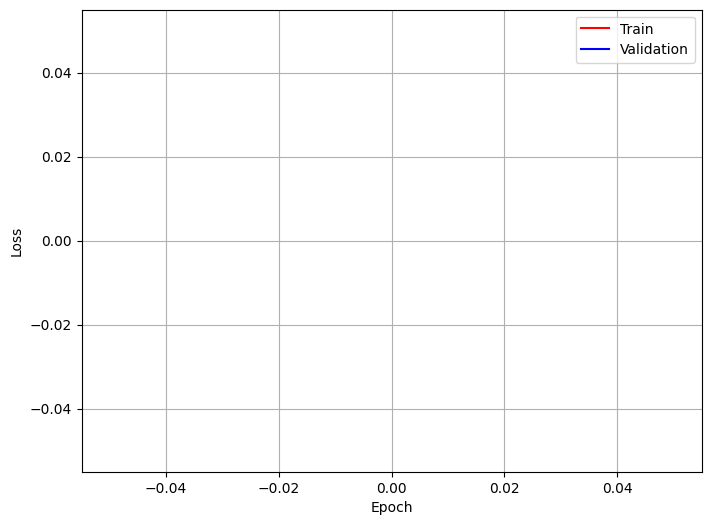

In [ ]:
plt.figure(figsize = (8, 6))

plt.plot(range(epoch_counter), loss_train_hist, 'r-', label = "Train")
plt.plot(range(epoch_counter), loss_valid_hist, 'b-', label = "Validation")

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

plt.show()

# 🔴 **Test**

In [ ]:
model_path = 'model.pt'
model = torch.load(model_path)
model.eval()

In [ ]:
_, metric_train = evaluate(model, train_loader, loss_fn, metric)
_, metric_valid = evaluate(model, valid_loader, loss_fn, metric)
_, metric_test = evaluate(model, test_loader, loss_fn, metric)

# 🔴 **Inference**

In [ ]:
import cv2
import torchvision.transforms as T

def predict_single_image(model, image_path, device):
    model.eval()

    # پیش‌پردازش استاندارد بدون Augmentation
    transform = T.Compose([
        T.Resize((128, 128)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        pred_age = model(input_tensor).item()

    print(f"Predicted Age: {pred_age:.1f} years")
    return pred_age


In [ ]:
model_path = 'model.pt'
model = torch.load(model_path)
model.eval()

FileNotFoundError: [Errno 2] No such file or directory: 'model.pt'

In [ ]:
!pip install face_recognition

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.1/100.1 MB 9.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for face-recognition-models: filename=face_recognition_models-0.3.0-py2.py3-none-any.whl size=100566166 sha256=2974748d65f9caa9c49b1becc08114572ec8b1758166ce96b57913de1b8c2227
  Stored in directory: /root/.cache/pip/wheels/8f/47/c8/f44c5aebb7507f7c8a2c0bd23151d732d0f0bd6884ad4ac635
Successfully built face-recognition-models


In [ ]:
import face_recognition

array([[[ 21,  22,  42],
        [ 21,  22,  42],
        [ 22,  23,  43],
        ...,
        [177, 196, 210],
        [195, 208, 224],
        [198, 212, 225]],

       [[ 20,  21,  41],
        [ 21,  22,  42],
        [ 21,  22,  42],
        ...,
        [186, 202, 218],
        [199, 211, 227],
        [202, 214, 230]],

       [[ 20,  21,  41],
        [ 20,  21,  41],
        [ 21,  22,  42],
        ...,
        [193, 204, 222],
        [202, 209, 228],
        [205, 212, 230]],

       ...,

       [[ 17,  23,  37],
        [ 17,  23,  37],
        [ 16,  22,  36],
        ...,
        [199, 210, 232],
        [199, 210, 232],
        [199, 210, 232]],

       [[ 16,  22,  36],
        [ 16,  22,  36],
        [ 16,  22,  36],
        ...,
        [199, 210, 232],
        [199, 210, 232],
        [199, 210, 232]],

       [[ 16,  22,  36],
        [ 16,  22,  36],
        [ 15,  21,  35],
        ...,
        [199, 210, 232],
        [199, 210, 232],
        [199, 210, 232]]], dtype=uint8)
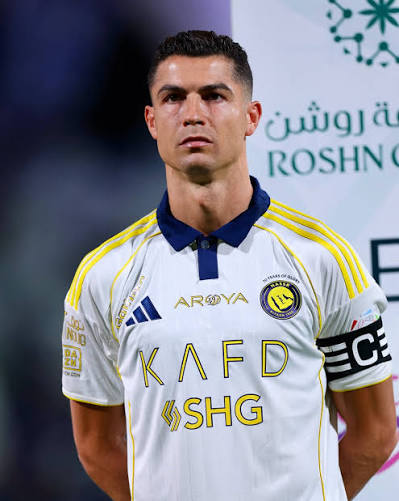

In [ ]:
img = face_recognition.load_image_file('ronaldo.jpg')
img

In [ ]:
top, right, bottom, left = face_recognition.face_locations(img)[0]
img_crop = img[top:bottom, left:right]
img_crop = Image.fromarray(img_crop)
img_tensor = test_transform(img_crop).unsqueeze(0).to(device)
img_tensor.shape

torch.Size([1, 3, 128, 128])

In [ ]:
with torch.inference_mode():
  preds = model(img_tensor).item()

In [ ]:
preds

51.32596206665039

In [ ]:
def inference(image_path, transform, model, face_detection = False):
  img = face_recognition.load_image_file(image_path)
  if face_detection:
    top, right, bottom, left = face_recognition.face_locations(img)[0]
    img_crop = img[top:bottom, left:right]
    #
    img_crop = Image.fromarray(img_crop)
    img_tensor = test_transform(img_crop).unsqueeze(0).to(device)
    #
    with torch.inference_mode():
      preds = model(img_tensor).item()

    return preds

  else:
    img_crop = Image.open(image_path).convert('RGB')
    img_tensor = test_transform(img_crop).unsqueeze(0).to(device)
    with torch.inference_mode():
      preds = model(img_tensor).item()
    return preds

In [ ]:
inference('ronaldo.jpg', test_transform, model, face_detection=True)

51.32596206665039

Real Age: 4, Predicted Age: 16.30268096923828


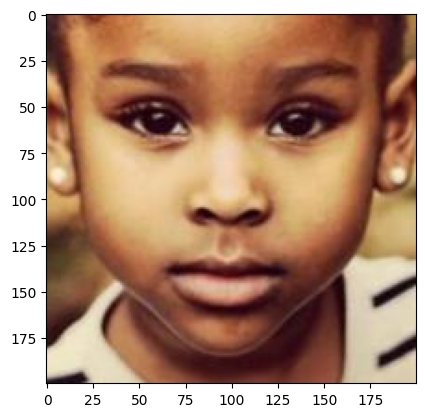

In [ ]:
# Load a random image from a folder
folder_image_path = '/content/UTKFace'
image_files = os.listdir(folder_image_path)
rand_idx = random.randint(0, len(image_files))
test_image_path = os.path.join(folder_image_path, image_files[rand_idx])
predicted_age = inference(test_image_path, test_transform, model, face_detection=False)

real_age = int(image_files[rand_idx].split('_')[0])
print(f'Real Age: {real_age}, Predicted Age: {predicted_age}')
image = Image.open(test_image_path)
plt.imshow(image)

Real Age: 28, Predicted Age: 31.55733871459961


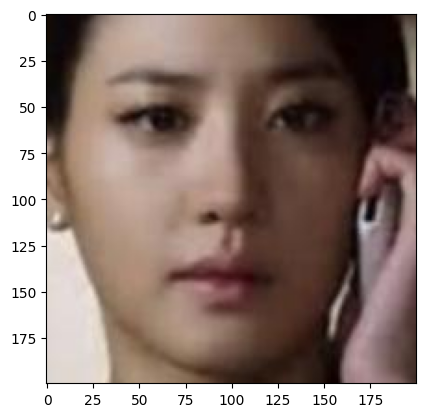

In [ ]:
# Load a image from a csv file
csv_file_path = '/content/test_set.csv'
df = pd.read_csv(csv_file_path)

rand_idx = random.randint(0, df.shape[0])
test_image_name = df.iloc[rand_idx].image_name
test_image_path = os.path.join(folder_image_path, test_image_name)
predicted_age = inference(test_image_path, test_transform, model, face_detection=False)

real_age = df.iloc[rand_idx].age
print(f'Real Age: {real_age}, Predicted Age: {predicted_age}')
image = Image.open(test_image_path)
plt.imshow(image)

# 🔴 **Experiments**

## 🟠 Analyze the loss value with respect to age, gender and race.

In [ ]:
all_outputs, all_targets = [], []

for inputs, targets in test_loader:
  inputs = inputs.to(device)
  targets = targets.to(device)

  with torch.inference_mode():
    outputs = model(inputs)

  all_outputs.append(outputs)
  all_targets.append(targets)



In [ ]:
all_outputs = torch.vstack(all_outputs).squeeze()
all_targets = torch.vstack(all_targets).squeeze()

all_outputs.shape, all_targets.shape

(torch.Size([3475]), torch.Size([3475]))

In [ ]:
mae = F.l1_loss(all_outputs, all_targets, reduction='none')
mae

tensor([14.1927,  3.4727,  7.7461,  ...,  3.3681, 35.1319,  0.1281],
       device='cuda:0')

In [ ]:
mae.shape

torch.Size([3475])

In [ ]:
df_test = pd.read_csv('test_set.csv')
df_test.head()

,image_name,age,ethnicity,gender
0,56_1_2_20170109010140329.jpg.chip.jpg,56,Asian,Female
1,48_1_1_20170110120129624.jpg.chip.jpg,48,Black,Female
2,34_0_0_20170119180157900.jpg.chip.jpg,34,White,Male
3,46_1_3_20170119202150389.jpg.chip.jpg,46,Indian,Female
4,4_0_4_20161221193322159.jpg.chip.jpg,4,Others,Male


In [ ]:
df_test['preds'] = all_outputs.cpu()
df_test['maes'] = mae.cpu()
df_test.to_csv('test_set.csv')
df_test.head()


,image_name,age,ethnicity,gender,preds,maes
0,56_1_2_20170109010140329.jpg.chip.jpg,56,Asian,Female,48.192715,14.192715
1,48_1_1_20170110120129624.jpg.chip.jpg,48,Black,Female,1.527322,3.472678
2,34_0_0_20170119180157900.jpg.chip.jpg,34,White,Male,63.746117,7.746117
3,46_1_3_20170119202150389.jpg.chip.jpg,46,Indian,Female,42.922173,17.922173
4,4_0_4_20161221193322159.jpg.chip.jpg,4,Others,Male,1.058444,0.058444


In [ ]:
df_test.groupby('age').describe()

preds                                                                    \
     count       mean        std        min        25%        50%        75%   
age                                                                            
1    168.0  28.593338  15.828767   1.257472  21.877417  26.829267  33.845932   
2     72.0  28.571655  16.893595   1.204326  21.869305  27.025335  37.035070   
3     43.0  25.921507  13.707674   1.718734  22.021699  26.446159  30.087355   
4     41.0  27.198376  14.780792   1.872415  21.831701  25.331329  35.577080   
5     29.0  26.087111  13.444743   2.226668  21.022137  24.387749  28.450125   
..     ...        ...        ...        ...        ...        ...        ...   
76     8.0  35.449158  22.706785   3.276569  25.765064  29.793329  42.626097   
77     4.0  37.945290  13.602401  25.740873  30.194335  34.476591  42.227549   
78    10.0  34.339417  17.181105   1.842710  23.396747  35.052629  45.815150   
79     3.0  46.303928  14.629249  37.133247  37.868401  38.603554  50.889271   
80    20.0  26.996677  15.047579   2.009144  20.925472  26.579168  35.884148   

                 maes                                                       \
           max  count       mean        std       min       25%        50%   
age                                                                          
1    80.201744  168.0   6.727075   6.268831  0.036575  2.006481   4.959300   
2    76.294334   72.0   6.395460   7.900930  0.083377  1.277186   2.918427   
3    61.010502   43.0   5.951278   6.021464  0.044586  1.570822   3.799657   
4    58.290451   41.0   9.456434  10.633936  0.114250  3.253292   6.496786   
5    57.049225   29.0   8.535257  10.439344  0.022137  1.526703   4.805040   
..         ...    ...        ...        ...       ...       ...        ...   
76   77.717201    8.0  10.827294   7.794023  0.762680  6.418079   7.342417   
77   57.087112    4.0  11.098265   6.349699  4.259127  7.305665  10.523409   
78   58.390938   10.0   5.577308   3.335280  0.491829  3.244146   6.640764   
79   63.174988    3.0  12.029404   7.216916  3.825012  9.345882  14.866753   
80   62.561409   20.0   7.801590   9.998224  0.653409  2.606455   5.787241   

                           
           75%        max  
age                        
1    10.188532  34.198700  
2     8.267400  35.995159  
3     9.623861  27.553841  
4    12.621895  53.369251  
5    10.776424  45.519505  
..         ...        ...  
76   16.906407  22.667664  
77   14.316008  19.087112  
78    7.871761   9.587700  
79   16.131599  17.396446  
80    8.387586  47.229763  

[80 rows x 16 columns]

In [ ]:
df_test.groupby('age')['maes'].describe()

,count,mean,std,min,25%,50%,75%,max
age,,,,,,,,
1,168.0,6.727075,6.268831,0.036575,2.006481,4.959300,10.188532,34.198700
2,72.0,6.395460,7.900930,0.083377,1.277186,2.918427,8.267400,35.995159
3,43.0,5.951278,6.021464,0.044586,1.570822,3.799657,9.623861,27.553841
4,41.0,9.456434,10.633936,0.114250,3.253292,6.496786,12.621895,53.369251
5,29.0,8.535257,10.439344,0.022137,1.526703,4.805040,10.776424,45.519505
...,...,...,...,...,...,...,...,...
76,8.0,10.827294,7.794023,0.762680,6.418079,7.342417,16.906407,22.667664
77,4.0,11.098265,6.349699,4.259127,7.305665,10.523409,14.316008,19.087112
78,10.0,5.577308,3.335280,0.491829,3.244146,6.640764,7.871761,9.587700


<BarContainer object of 80 artists>

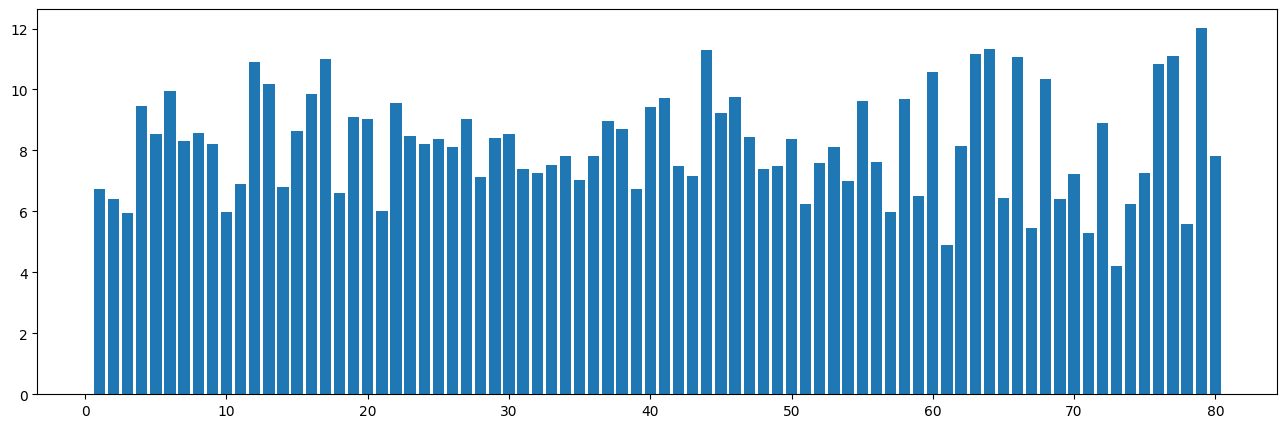

In [ ]:
plt.figure(figsize=(16, 5))
plt.bar(df_test.groupby('age')['maes'].describe().index, df_test.groupby('age')['maes'].describe()['mean'])

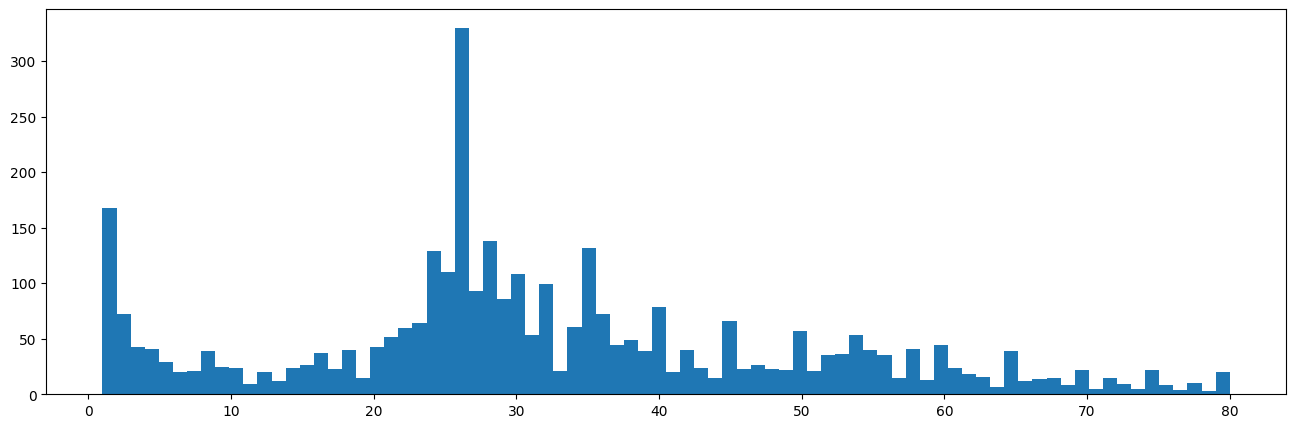

In [ ]:
plt.figure(figsize=(16, 5))
plt.hist(df_test.age, bins=len(df_test.age.unique()));

In [ ]:
df_test.groupby('gender')['maes'].describe()

,count,mean,std,min,25%,50%,75%,max
gender,,,,,,,,
Female,1660.0,7.839644,8.100526,0.007133,1.746399,5.025956,11.355113,53.369251
Male,1815.0,8.211390,8.053593,0.006823,2.221697,5.680332,11.505335,57.241142


In [ ]:
df_test.groupby('ethnicity')['maes'].describe()

,count,mean,std,min,25%,50%,75%,max
ethnicity,,,,,,,,
Asian,513.0,7.232056,7.503079,0.006823,1.732182,4.804314,10.047077,47.229763
Black,724.0,7.746258,8.100345,0.010452,1.770198,5.052540,10.726642,50.301689
Indian,563.0,8.237035,7.875223,0.047493,2.184487,5.803570,11.808321,45.780388
Others,246.0,8.562869,8.519570,0.063767,2.213362,5.621056,12.778270,53.369251
White,1429.0,8.296172,8.248430,0.009781,2.109718,5.628914,11.971733,57.241142


In [ ]:
ranges = np.arange(df.age.min()-1, df.age.max()+1, 5)
df_test['age_period'] = pd.cut(df_test.age, ranges)
df_test

,image_name,age,ethnicity,gender,preds,maes,age_period
0,56_1_3_20170109132208103.jpg.chip.jpg,56,Indian,Female,27.337463,0.662537,"(55, 60]"
1,48_0_3_20170119202007642.jpg.chip.jpg,48,Indian,Male,2.422925,1.422925,"(45, 50]"
2,34_0_0_20170116030432644.jpg.chip.jpg,34,White,Male,29.804338,3.804338,"(30, 35]"
3,46_0_1_20170113175110660.jpg.chip.jpg,46,Black,Male,20.929123,20.070877,"(45, 50]"
4,4_1_3_20161219230403672.jpg.chip.jpg,4,Indian,Female,1.872415,0.872415,"(0, 5]"
...,...,...,...,...,...,...,...
3470,28_0_0_20170113161024162.jpg.chip.jpg,28,White,Male,26.730839,7.269161,"(25, 30]"
3471,26_1_4_20170117154150500.jpg.chip.jpg,26,Others,Female,7.017025,24.982975,"(25, 30]"
3472,34_1_1_20170116231528550.jpg.chip.jpg,34,Black,Female,28.035891,3.964109,"(30, 35]"
3473,60_0_0_20170120223121330.jpg.chip.jpg,60,White,Male,18.882694,5.882694,"(55, 60]"


In [ ]:

df_test.groupby('age_period')['maes'].describe().index


/tmp/ipykernel_1943/2967776095.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test.groupby('age_period')['maes'].describe().index


CategoricalIndex([  (0, 5],  (5, 10], (10, 15], (15, 20], (20, 25], (25, 30],
                  (30, 35], (35, 40], (40, 45], (45, 50], (50, 55], (55, 60],
                  (60, 65], (65, 70], (70, 75], (75, 80]],
                 categories=[(0, 5], (5, 10], (10, 15], (15, 20], ..., (60, 65], (65, 70], (70, 75], (75, 80]], ordered=True, dtype='category', name='age_period')

<Figure size 1600x500 with 0 Axes>

/tmp/ipykernel_1943/1123385392.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test.groupby('age_period')['maes'].describe()['mean'])


<BarContainer object of 16 artists>

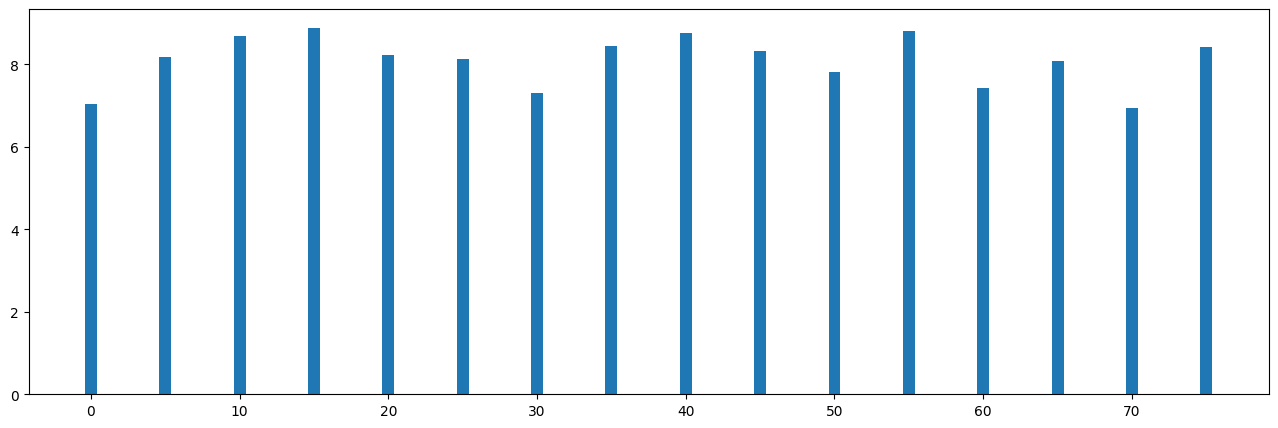

In [ ]:
plt.figure(figsize=(16, 5))
plt.bar(ranges[:-1],
        df_test.groupby('age_period')['maes'].describe()['mean'])

In [ ]:
df_test.groupby('age_period')['maes'].describe()

/tmp/ipykernel_1943/1733539966.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_test.groupby('age_period')['maes'].describe()


,count,mean,std,min,25%,50%,75%,max
age_period,,,,,,,,
"(0, 5]",353.0,7.030490,7.630307,0.022137,1.578236,4.634617,10.298794,53.369251
"(5, 10]",129.0,8.189115,6.936881,0.058542,2.764038,6.363586,11.887758,34.507866
"(10, 15]",91.0,8.677876,8.164220,0.130489,2.911183,5.852310,12.898772,34.398254
"(15, 20]",158.0,8.893173,8.546182,0.062887,2.373386,5.577729,13.096156,37.455933
"(20, 25]",415.0,8.219021,8.266542,0.009781,2.002059,5.402102,11.397479,51.044563
"(25, 30]",755.0,8.137782,8.275561,0.007133,1.859627,5.307358,11.867684,50.301689
"(30, 35]",366.0,7.306093,7.097204,0.010452,2.131972,5.241858,10.765391,57.241142
"(35, 40]",283.0,8.451667,8.518859,0.038118,2.211944,5.720936,12.761518,47.752533
"(40, 45]",165.0,8.757157,8.601944,0.091301,2.196800,7.057930,12.509796,51.378296


## 🟠 Analyze the model's sensitivity.

 26.90


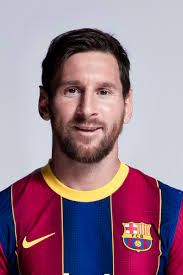

In [ ]:
test_image_path = '/content/messi.jpg'
img = Image.open(test_image_path).convert('RGB')

img_tensor = test_transform(img).unsqueeze(0).to(device)

with torch.inference_mode():
  predicted_age = model(img_tensor).item()
print(f'{predicted_age: .2f}')

img


 25.28


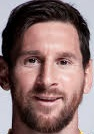

In [ ]:
test_image_path = '/content/messi_crop.jpg'
img = Image.open(test_image_path).convert('RGB')

img_tensor = test_transform(img).unsqueeze(0).to(device)

with torch.inference_mode():
  predicted_age = model(img_tensor).item()
print(f'{predicted_age: .2f}')

img
